In [3]:
import pandas as pd

df = pd.read_csv("../data/CC GENERAL.csv")

In [4]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
df.shape

(8950, 18)

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [7]:
df.isnull().sum()


CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [8]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [9]:
df.isnull().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

In [10]:
df.drop(['CUST_ID'], axis=1, inplace=True)

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

In [13]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)

df['Cluster'] = kmeans.fit_predict(scaled_data)

In [14]:
df.groupby('Cluster').mean()


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,5023.958508,0.967107,721.184928,453.485000,267.804742,5075.737329,0.329511,0.161791,0.220253,0.510058,15.831959,10.420619,8215.313964,4176.805950,2227.858327,0.040022,11.414433
1,109.464707,0.412883,351.589913,191.487250,160.571811,299.684391,0.320703,0.072810,0.235009,0.035164,0.732394,4.812877,3628.936958,1036.107793,252.929103,0.253098,11.216633
2,1253.422099,0.974766,2181.418772,1241.370362,940.311888,234.489319,0.928436,0.390092,0.748134,0.041704,0.807310,32.718820,5120.665715,2147.982881,784.272825,0.282880,11.727477
3,1500.348531,0.966640,282.216074,209.226223,73.305481,789.088912,0.206247,0.097865,0.108084,0.157946,3.000000,3.655490,3226.815035,954.225631,816.131081,0.022924,11.485460


In [15]:
df.groupby('Cluster').mean()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,5023.958508,0.967107,721.184928,453.485000,267.804742,5075.737329,0.329511,0.161791,0.220253,0.510058,15.831959,10.420619,8215.313964,4176.805950,2227.858327,0.040022,11.414433
1,109.464707,0.412883,351.589913,191.487250,160.571811,299.684391,0.320703,0.072810,0.235009,0.035164,0.732394,4.812877,3628.936958,1036.107793,252.929103,0.253098,11.216633
2,1253.422099,0.974766,2181.418772,1241.370362,940.311888,234.489319,0.928436,0.390092,0.748134,0.041704,0.807310,32.718820,5120.665715,2147.982881,784.272825,0.282880,11.727477
3,1500.348531,0.966640,282.216074,209.226223,73.305481,789.088912,0.206247,0.097865,0.108084,0.157946,3.000000,3.655490,3226.815035,954.225631,816.131081,0.022924,11.485460


In [16]:
df.to_csv("../output/results.csv", index=False)

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

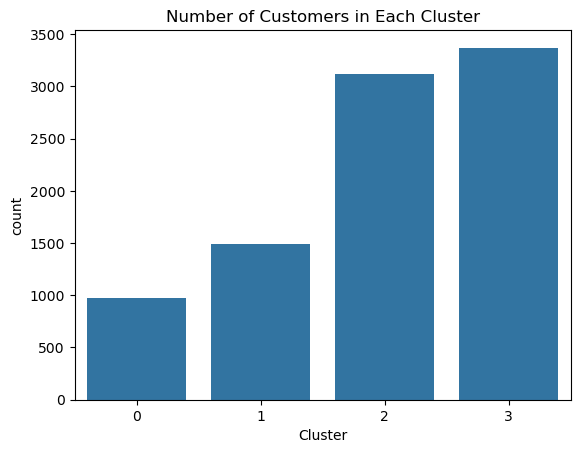

In [18]:
sns.countplot(x='Cluster', data=df)
plt.title("Number of Customers in Each Cluster")
plt.show()

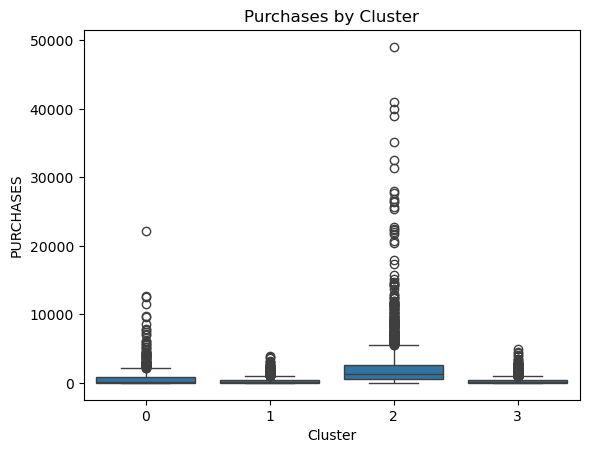

In [19]:
sns.boxplot(x='Cluster', y='PURCHASES', data=df)
plt.title("Purchases by Cluster")
plt.show()

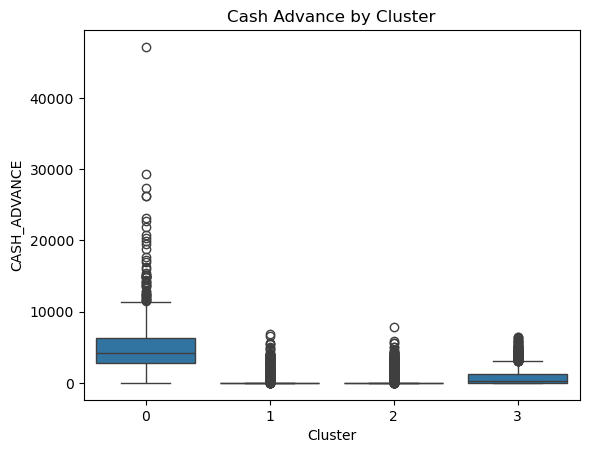

In [20]:
sns.boxplot(x='Cluster', y='CASH_ADVANCE', data=df)
plt.title("Cash Advance by Cluster")
plt.show()

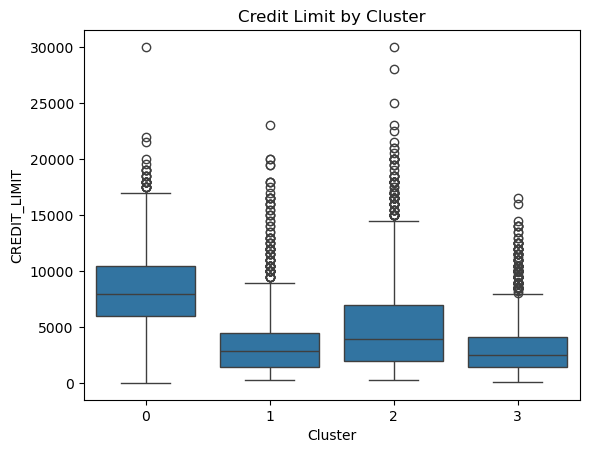

In [21]:
sns.boxplot(x='Cluster', y='CREDIT_LIMIT', data=df)
plt.title("Credit Limit by Cluster")
plt.show()


# Smart Card Customer Segmentation Project
## 📊 Customer Segmentation Insights

# **Cluster 0:** High balance and high cash advance users (Risky customers) ⚠️
# **Cluster 1:** Low balance and low activity users 😴
# **Cluster 2:** High purchase and frequent users (High value customers) 💰
# **Cluster 3:** Moderate users ⚖️


## 📌 Project Overview

This project focuses on customer segmentation using K-Means clustering on credit card data. The goal is to group customers based on their spending behavior and identify high-value and risky users.

## 📂 Dataset Description

The dataset contains information about credit card customers including balance, purchases, cash advances, and payment behavior. It has 8950 records and 18 features.

## 🛠️ Tools & Technologies

- Python  
- Pandas  
- Scikit-learn  
- Matplotlib & Seaborn  

In [22]:
import os

os.makedirs("../output", exist_ok=True)
df.to_csv("../output/results.csv", index=False)
